<a href="https://colab.research.google.com/github/m-manuelmussa/Machine-Learning-QSAR-2D-TKI-HER2-2025/blob/main/4_Machine_Learning_Engineer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Desenvolvimento de modelos de machine learning baseados em QSAR-2D para a predição de novos candidatos a fármacos TKI-HER2 para o tratamento de câncer da mama***

---



*@Micliete_Mussa*

### ***2. Machine Learning & QSAR-2D***

In [ ]:
# Instalação de frameworks
!pip install rdkit # Manipulação de compostos
!pip install lazypredict # Selecção de modelos robustos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 703.4/703.4 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 12.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd # Tabulação de dados
import numpy as np # Cálculos matemáticos
from sklearn.feature_selection import VarianceThreshold # Cálculo de variância das fingerprints
from sklearn.model_selection import train_test_split # Divisão de dados para o treino e teste
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lazypredict.Supervised import LazyRegressor
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import string
import shap
import os


In [ ]:
df = pd.read_csv('Dados para EDA.csv')
y = df['pIC50']

In [ ]:
# Selecionar colunas de fingerprints
fp_cols = [col for col in df.columns if col.startswith('PubChemFP_')]
print(f"Número de fingerprints carregados: {len(fp_cols)}")

# Remover baixa variância
def remove_low_variance(X, threshold=0.1):
    selector = VarianceThreshold(threshold=threshold)
    X_reduced = selector.fit_transform(X)
    selected_columns = X.columns[selector.get_support()]
    return pd.DataFrame(X_reduced, columns=selected_columns, index=X.index)

X = df[fp_cols]
X_low_var = remove_low_variance(X, threshold=0.1)
print(f"Número de fingerprints após remover baixa variância: {X_low_var.shape[1]}")


# Divisão Holdout 80/20
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X_low_var, y, test_size=0.2, random_state=42
)
print(f"Tamanho treino: {x_treino.shape[0]}")
print(f"Tamanho teste: {x_teste.shape[0]}")

Número de fingerprints carregados: 881
Número de fingerprints após remover baixa variância: 653
Tamanho treino: 2155
Tamanho teste: 539


In [ ]:
# LazyPredict com dados originais de teste
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
modelos, preds = reg.fit(
    x_treino, x_teste,
    y_treino, y_teste
)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1959
[LightGBM] [Info] Number of data points in the train set: 2155, number of used features: 653
[LightGBM] [Info] Start training from score 6.400209


In [ ]:
modelos

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
KernelRidge,133.81,-27.39,6.59,1.26
GaussianProcessRegressor,123.25,-25.13,6.32,18.40
RANSACRegressor,58.81,-11.36,4.35,25.01
Lars,35.48,-6.37,3.36,0.86
QuantileRegressor,5.71,-0.01,1.24,2.92
Lasso,5.69,-0.00,1.24,0.10
DummyRegressor,5.69,-0.00,1.24,0.12
LassoLars,5.69,-0.00,1.24,0.23
ElasticNet,5.65,0.01,1.23,0.23


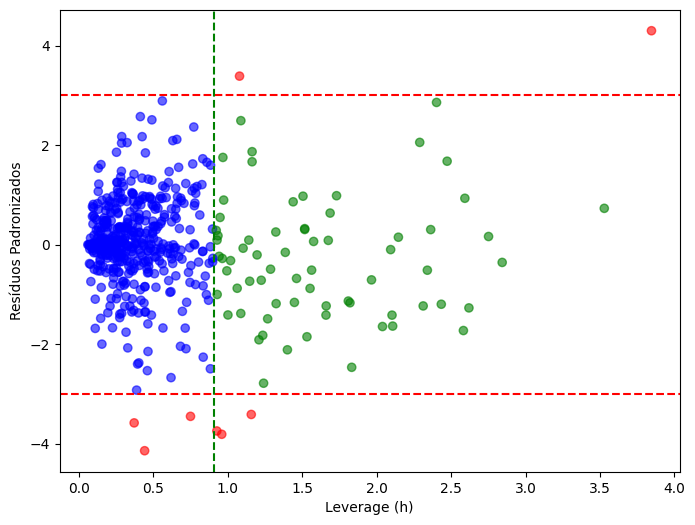

In [ ]:
# =========================
# 1. Escolher um modelo treinado (ex: RandomForest do LazyPredict)
# =========================
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(random_state=42)
modelo.fit(x_treino, y_treino)
y_pred_teste = modelo.predict(x_teste)

# =========================
# 2. Garantir que os dados sejam arrays NumPy
# =========================
X_treino_np = np.hstack([np.ones((len(x_treino), 1)), np.asarray(x_treino, dtype=float)])
X_teste_np  = np.hstack([np.ones((len(x_teste), 1)),  np.asarray(x_teste, dtype=float)])
y_teste_np  = np.asarray(y_teste, dtype=float)
y_pred_teste_np = np.asarray(y_pred_teste, dtype=float)

# =========================
# 3. Calcular resíduos padronizados
# =========================
residuos = y_teste_np - y_pred_teste_np
residuos_std = (residuos - np.mean(residuos)) / np.std(residuos)

# =========================
# 4. Calcular leverage (baseado no espaço do treino)
# =========================
H_teste = X_teste_np @ np.linalg.inv(X_treino_np.T @ X_treino_np) @ X_teste_np.T
leverage = np.diag(H_teste)

# Limite de leverage
n_treino = X_treino_np.shape[0]
p = X_treino_np.shape[1] - 1   # sem contar intercepto
h_limite = 3 * (p + 1) / n_treino

# =========================
# 5. Classificar cores dos pontos
# =========================
cores = []
for i in range(len(residuos_std)):
    if abs(residuos_std[i]) > 3:          # erro grande
        cores.append('red')
    elif leverage[i] > h_limite:          # fora do domínio
        cores.append('green')
    else:                                 # normal
        cores.append('blue')

# =========================
# 6. Plot Williams
# =========================
plt.figure(figsize=(8,6))
plt.scatter(leverage, residuos_std, c=cores, alpha=0.6)

# Linhas de corte
plt.axhline(3, color="red", linestyle="--")
plt.axhline(-3, color="red", linestyle="--")
plt.axvline(h_limite, color="green", linestyle="--")

# Labels e título
plt.xlabel("Leverage (h)")
plt.ylabel("Resíduos Padronizados")

plt.savefig("williams_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# 1. Criar máscara do Williams Plot
# =========================
mascara_normais = (np.abs(residuos_std) <= 3) & (leverage <= h_limite)

X_teste_williams = x_teste.loc[mascara_normais]
y_teste_williams = y_teste.loc[mascara_normais]

print(f"Tamanho original do teste: {len(x_teste)}")
print(f"Após Williams plot: {len(X_teste_williams)} (removidos {len(x_teste) - len(X_teste_williams)})")

# =========================
# 2. Calcular resíduos no teste filtrado (usando um modelo auxiliar só p/ pegar resíduos)
# =========================
from sklearn.ensemble import HistGradientBoostingRegressor
modelo_aux = HistGradientBoostingRegressor(random_state=42)
modelo_aux.fit(X_treino_np[:,1:], y.loc[x_treino.index])

y_pred_williams = modelo_aux.predict(X_teste_williams.values)

# =========================
# 3. Remover outliers adicionais (resíduos > 2σ)
# =========================
residuos_teste = y_teste_williams.values - y_pred_williams
desvio_padrao_teste = np.std(residuos_teste)
limite_teste = 2.0 * desvio_padrao_teste

mask_sem_outliers_teste = np.abs(residuos_teste) <= limite_teste

X_teste_final = X_teste_williams.loc[mask_sem_outliers_teste]
y_teste_final = y_teste_williams.loc[mask_sem_outliers_teste]

print(f"Após remoção 2σ: {len(X_teste_final)} (removidos {len(X_teste_williams) - len(X_teste_final)})")


# =========================
# 6. Rodar LazyPredict - Williams + outliers 2σ
# =========================
reg_final = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models_final, preds_final = reg_final.fit(
    X_treino_np[:, 1:],   # X treino
    X_teste_final,        # X teste filtrado (Williams + 2σ)
    y.loc[x_treino.index],# y treino
    y_teste_final         # y teste filtrado
)

# =========================
# 7. Comparar resultados
display(models_final)

Tamanho original do teste: 539
Após Williams plot: 463 (removidos 76)
Após remoção 2σ: 435 (removidos 28)


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018655 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1959
[LightGBM] [Info] Number of data points in the train set: 2155, number of used features: 653
[LightGBM] [Info] Start training from score 6.400209


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
KernelRidge,68.03,-32.82,6.57,1.75
GaussianProcessRegressor,64.58,-31.08,6.40,5.47
RANSACRegressor,17.30,-7.23,3.24,17.60
Lars,9.80,-3.44,2.38,1.51
Lasso,3.04,-0.03,1.15,0.15
LassoLars,3.04,-0.03,1.15,0.12
DummyRegressor,3.04,-0.03,1.15,0.05
ElasticNet,3.02,-0.02,1.14,0.07
QuantileRegressor,2.98,-0.00,1.13,2.30


,Grupo,Média Tanimoto
0,Treino,0.61
1,Teste,0.63
2,Treino Vs Teste,0.62


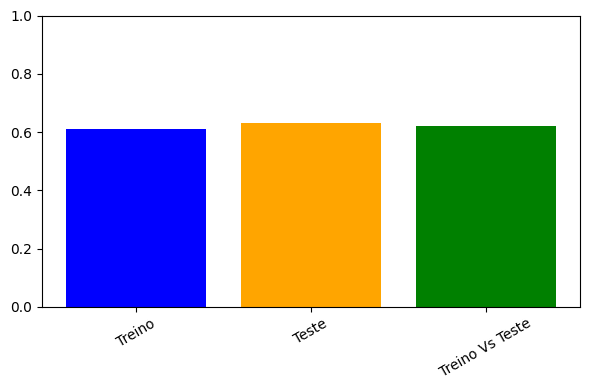

In [ ]:
from rdkit import DataStructs
# =========================
# Converter DataFrame de fingerprints em ExplicitBitVect
# =========================
def to_bitvect_matrix(X):
    fps = []
    for row in X.values:
        arr = row.astype(int).tolist()
        bv = DataStructs.CreateFromBitString("".join(map(str, arr)))
        fps.append(bv)
    return fps

# =========================
# Calcular média de similaridade Tanimoto
# =========================
def calc_tanimoto_mean(fps1, fps2=None):
    valores = []
    if fps2 is None:  # intra-grupo
        for i in range(len(fps1)):
            for j in range(i+1, len(fps1)):
                valores.append(DataStructs.TanimotoSimilarity(fps1[i], fps1[j]))
    else:  # inter-grupo
        for fp1 in fps1:
            for fp2 in fps2:
                valores.append(DataStructs.TanimotoSimilarity(fp1, fp2))
    return float(np.mean(valores))

# =========================
# 1. Converter treino e teste limpo
# =========================
fps_treino = to_bitvect_matrix(x_treino)
fps_teste  = to_bitvect_matrix(X_teste_final)

# =========================
# 2. Calcular médias intra e inter
# =========================
media_intra_treino = calc_tanimoto_mean(fps_treino)
media_intra_teste  = calc_tanimoto_mean(fps_teste)
media_inter        = calc_tanimoto_mean(fps_treino, fps_teste)

# =========================
# 3. Organizar em DataFrame
# =========================
df_media = pd.DataFrame({
    "Grupo": ["Treino", "Teste", "Treino Vs Teste"],
    "Média Tanimoto": [media_intra_treino, media_intra_teste, media_inter]
})

display(df_media)

# =========================
# 4. Gráfico de barras
# =========================
plt.figure(figsize=(6,4))
plt.bar(df_media["Grupo"], df_media["Média Tanimoto"], color=["blue","orange","green"])
plt.ylim(0,1)
plt.xticks(rotation=30)
# salvar em PNG
plt.tight_layout()
plt.savefig("Tanimoto_Similarity.png", dpi=300)  # alta resolução
plt.show()

In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, BaggingRegressor

# Treinar manualmente
best_lgbm = LGBMRegressor(random_state=42).fit(x_treino, y_treino)
best_xgb  = XGBRegressor(random_state=42).fit(x_treino, y_treino)
best_rf   = RandomForestRegressor(random_state=42).fit(x_treino, y_treino)
best_hgb  = HistGradientBoostingRegressor(random_state=42).fit(x_treino, y_treino)
best_bag  = BaggingRegressor(random_state=42).fit(x_treino, y_treino)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1306
[LightGBM] [Info] Number of data points in the train set: 2155, number of used features: 653
[LightGBM] [Info] Start training from score 6.400209


In [ ]:
# Lista de modelos treinados
modelos_finais = {
    "LGBM": best_lgbm,
    "HistGradientBoosting": best_hgb,
    "RandomForest": best_rf,
    "Bagging": best_bag,
    "XGB": best_xgb
}

resultados = []

for nome, modelo in modelos_finais.items():
    # Previsões
    y_pred_train = modelo.predict(x_treino)
    y_pred_test  = modelo.predict(X_teste_final)

    # Métricas
    r2_train = r2_score(y_treino, y_pred_train)
    r2_test  = r2_score(y_teste_final, y_pred_test)
    gap      = r2_train - r2_test
    rmse     = np.sqrt(mean_squared_error(y_teste_final, y_pred_test))
    mae      = mean_absolute_error(y_teste_final, y_pred_test)

    resultados.append([nome, r2_train, r2_test, gap, rmse, mae])

# Criar DataFrame
df_resultados_williams = pd.DataFrame(resultados, columns=["Modelo", "R2 Treino", "R2 Teste", "Gap", "RMSE", "MAE"])
df_resultados_williams = df_resultados_williams.sort_values(by="R2 Teste", ascending=False).reset_index(drop=True)

In [ ]:
display(df_resultados_williams)

,Modelo,R2 Treino,R2 Teste,Gap,RMSE,MAE
0,LGBM,0.92,0.85,0.07,0.44,0.34
1,HistGradientBoosting,0.92,0.85,0.07,0.44,0.34
2,RandomForest,0.95,0.84,0.11,0.45,0.34
3,XGB,0.99,0.82,0.17,0.48,0.35
4,Bagging,0.93,0.80,0.13,0.51,0.38


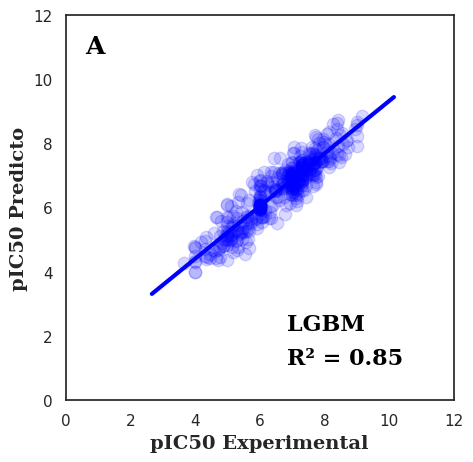

In [ ]:
sns.set_style("white")
sns.set_context("notebook")

# Modelo
nome = "LGBM"
modelo = best_lgbm

# Previsões
y_predito = modelo.predict(X_teste_final)
y_teste_np = np.array(y_teste_final)
y_predito_np = np.array(y_predito)

# Calcular R²
r2 = r2_score(y_teste_np, y_predito_np)

# Ajustar linha de regressão
lr = LinearRegression()
lr.fit(y_teste_np.reshape(-1,1), y_predito_np)
x_range = np.linspace(y_teste_np.min()-1, y_teste_np.max()+1, 100).reshape(-1,1)
y_range = lr.predict(x_range)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_teste_np, y_predito_np, alpha=0.15, s=80, color='blue')
ax.plot(x_range, y_range, color='blue', lw=3)

# Labels
ax.set_xlabel('pIC50 Experimental', fontsize=14, fontweight='bold', family='DejaVu Serif')
ax.set_ylabel('pIC50 Predicto', fontsize=14, fontweight='bold', family='DejaVu Serif')

# Limites consistentes
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Letra A
ax.text(0.05, 0.95, 'A', fontsize=18, color='black', fontweight='bold',
        ha='left', va='top', transform=ax.transAxes, family='DejaVu Serif')

# Nome do modelo + R²
ax.text(0.77, 0.17, nome, fontsize=16, color='black', fontweight='bold',
        ha='right', va='bottom', transform=ax.transAxes, family='DejaVu Serif')
ax.text(0.87, 0.08, f"R\u00b2 = {r2:.2f}", fontsize=16, color='black',
        ha='right', va='bottom', transform=ax.transAxes, fontweight='bold', family='DejaVu Serif')
fig.savefig("A_LGBM.png", dpi=300, bbox_inches='tight')
plt.show()

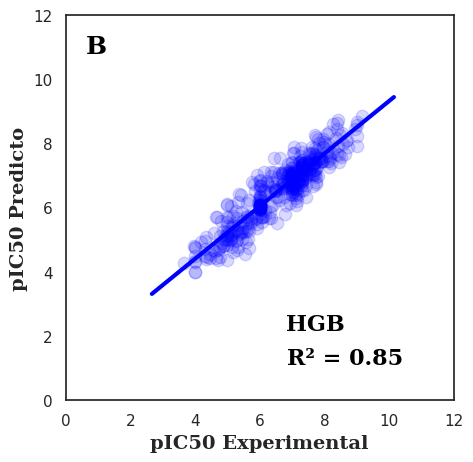

In [ ]:
sns.set_style("white")
sns.set_context("notebook")

# Modelo
nome = "HGB"
modelo = best_hgb

# Previsões
y_predito = modelo.predict(X_teste_final)
y_teste_np = np.array(y_teste_final)
y_predito_np = np.array(y_predito)

# Calcular R²
r2 = r2_score(y_teste_np, y_predito_np)

# Ajustar linha de regressão
lr = LinearRegression()
lr.fit(y_teste_np.reshape(-1,1), y_predito_np)
x_range = np.linspace(y_teste_np.min()-1, y_teste_np.max()+1, 100).reshape(-1,1)
y_range = lr.predict(x_range)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_teste_np, y_predito_np, alpha=0.15, s=80, color='blue')
ax.plot(x_range, y_range, color='blue', lw=3)

# Labels
ax.set_xlabel('pIC50 Experimental', fontsize=14, fontweight='bold', family='DejaVu Serif')
ax.set_ylabel('pIC50 Predicto', fontsize=14, fontweight='bold', family='DejaVu Serif')

# Limites consistentes
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Letra B
ax.text(0.05, 0.95, 'B', fontsize=18, color='black', fontweight='bold',
        ha='left', va='top', transform=ax.transAxes, family='DejaVu Serif')

# Nome do modelo + R²
ax.text(0.72, 0.17, nome, fontsize=16, color='black', fontweight='bold',
        ha='right', va='bottom', transform=ax.transAxes, family='DejaVu Serif')
ax.text(0.87, 0.08, f"R\u00b2 = {r2:.2f}", fontsize=16, color='black',
        ha='right', va='bottom', transform=ax.transAxes, fontweight='bold', family='DejaVu Serif')

fig.savefig("B_HistGradientBoosting.png", dpi=300, bbox_inches='tight')
plt.show()

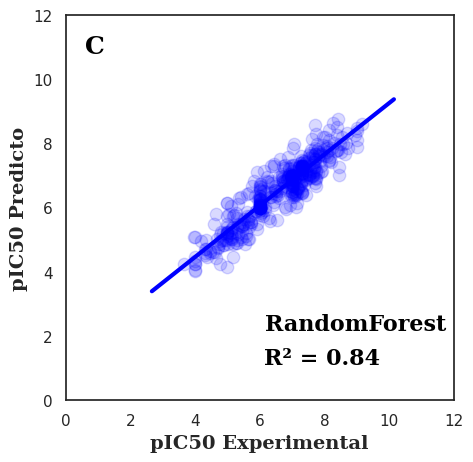

In [ ]:
# Modelo
nome = "RandomForest"
modelo = best_rf

# Previsões
y_predito = modelo.predict(X_teste_final)
y_teste_np = np.array(y_teste_final)
y_predito_np = np.array(y_predito)

# Calcular R²
r2 = r2_score(y_teste_np, y_predito_np)

# Ajustar linha de regressão
lr = LinearRegression()
lr.fit(y_teste_np.reshape(-1,1), y_predito_np)
x_range = np.linspace(y_teste_np.min()-1, y_teste_np.max()+1, 100).reshape(-1,1)
y_range = lr.predict(x_range)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_teste_np, y_predito_np, alpha=0.15, s=80, color='blue')
ax.plot(x_range, y_range, color='blue', lw=3)

# Labels
ax.set_xlabel('pIC50 Experimental', fontsize=14, fontweight='bold', family='DejaVu Serif')
ax.set_ylabel('pIC50 Predicto', fontsize=14, fontweight='bold', family='DejaVu Serif')

# Limites consistentes
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Letra C
ax.text(0.05, 0.95, 'C', fontsize=18, color='black', fontweight='bold',
        ha='left', va='top', transform=ax.transAxes, family='DejaVu Serif')

# Nome do modelo + R²
ax.text(0.98, 0.17, nome, fontsize=16, color='black', fontweight='bold',
        ha='right', va='bottom', transform=ax.transAxes, family='DejaVu Serif')
ax.text(0.81, 0.08, f"R\u00b2 = {r2:.2f}", fontsize=16, color='black',
        ha='right', va='bottom', transform=ax.transAxes, fontweight='bold', family='DejaVu Serif')

fig.savefig("C_RandomForest.png", dpi=300, bbox_inches='tight')
plt.show()

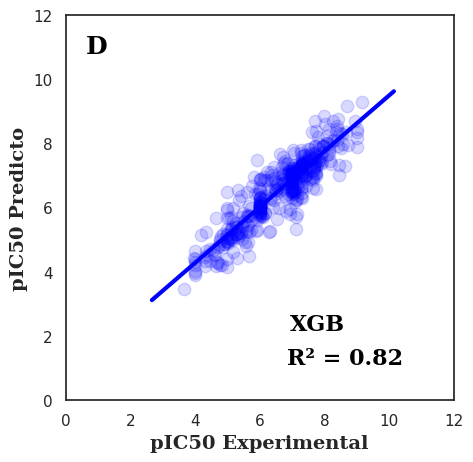

In [ ]:
# Modelo XGB
nome = "XGB"
modelo = best_xgb

# Previsões
y_predito = modelo.predict(X_teste_final)
y_teste_np = np.array(y_teste_final)
y_predito_np = np.array(y_predito)

# Calcular R²
r2 = r2_score(y_teste_np, y_predito_np)

# Ajustar modelo linear para a linha de regressão
lr = LinearRegression()
lr.fit(y_teste_np.reshape(-1,1), y_predito_np)

# Criar intervalo estendido para a linha
x_range = np.linspace(y_teste_np.min()-1, y_teste_np.max()+1, 100).reshape(-1,1)
y_range = lr.predict(x_range)

# Configuração do estilo
sns.set_style("white")
sns.set_context("notebook")

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_teste_np, y_predito_np, alpha=0.15, s=80, color='blue')
ax.plot(x_range, y_range, color='blue', lw=3)  # linha estendida

# Labels com DejaVu Serif
ax.set_xlabel('pIC50 Experimental', fontsize=14, fontweight='bold', family='DejaVu Serif')
ax.set_ylabel('pIC50 Predicto', fontsize=14, fontweight='bold', family='DejaVu Serif')

# Limites do gráfico
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Letra D no canto superior esquerdo
ax.text(0.05, 0.95, 'D', fontsize=18, color='black', fontweight='bold',
        ha='left', va='top', transform=ax.transAxes, family='DejaVu Serif')

# Nome do modelo - acima do R², mesmo alinhamento à direita
ax.text(0.72, 0.17, nome, fontsize=16, color='black', fontweight='bold',
        ha='right', va='bottom', transform=ax.transAxes, family='DejaVu Serif')

# R² - canto inferior direito, tudo em negrito, fonte DejaVu Serif
ax.text(0.87, 0.08, f"R\u00b2 = {r2:.2f}",
        fontsize=16, color='black',
        ha='right', va='bottom', transform=ax.transAxes,
        fontweight='bold', family='DejaVu Serif')

fig.savefig("D_XGB.png", dpi=300, bbox_inches='tight')
plt.show()

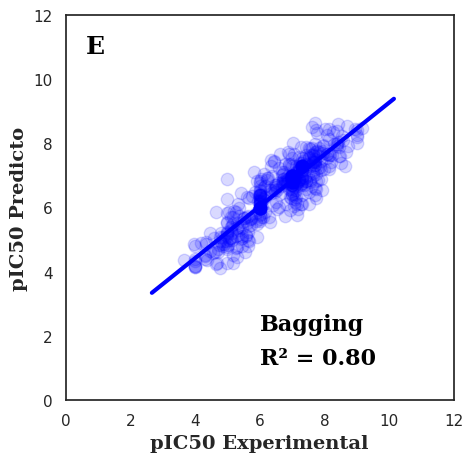

In [ ]:
# Modelo
nome = "Bagging"
modelo = best_bag

# Previsões
y_predito = modelo.predict(X_teste_final)
y_teste_np = np.array(y_teste_final)
y_predito_np = np.array(y_predito)

# Calcular R²
r2 = r2_score(y_teste_np, y_predito_np)

# Ajustar linha de regressão
lr = LinearRegression()
lr.fit(y_teste_np.reshape(-1,1), y_predito_np)
x_range = np.linspace(y_teste_np.min()-1, y_teste_np.max()+1, 100).reshape(-1,1)
y_range = lr.predict(x_range)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_teste_np, y_predito_np, alpha=0.15, s=80, color='blue')
ax.plot(x_range, y_range, color='blue', lw=3)

# Labels
ax.set_xlabel('pIC50 Experimental', fontsize=14, fontweight='bold', family='DejaVu Serif')
ax.set_ylabel('pIC50 Predicto', fontsize=14, fontweight='bold', family='DejaVu Serif')

# Limites consistentes
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Letra E
ax.text(0.05, 0.95, 'E', fontsize=18, color='black', fontweight='bold',
        ha='left', va='top', transform=ax.transAxes, family='DejaVu Serif')

# Nome do modelo + R²
ax.text(0.77, 0.17, nome, fontsize=16, color='black', fontweight='bold',
        ha='right', va='bottom', transform=ax.transAxes, family='DejaVu Serif')
ax.text(0.80, 0.08, f"R\u00b2 = {r2:.2f}", fontsize=16, color='black',
        ha='right', va='bottom', transform=ax.transAxes, fontweight='bold', family='DejaVu Serif')

fig.savefig("E_Bagging.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def plot_shap_bar(modelo, X, model_name, y_true, letra="A", save_path=None):
    # Verificar se é Bagging
    if isinstance(modelo, BaggingRegressor):
        base_model = modelo.estimators_[0]
        explainer = shap.TreeExplainer(base_model)
    else:
        explainer = shap.TreeExplainer(modelo)

    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Calcular SHAP médio absoluto
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    df_shap = pd.DataFrame({
        "Feature": X.columns,
        "MeanSHAP": mean_shap_values
    }).sort_values(by="MeanSHAP", ascending=False)

    # Top 9 + soma do resto
    top_n = 9
    top_features = df_shap.head(top_n)
    rest_sum = df_shap.iloc[top_n:]["MeanSHAP"].sum()
    final_df = top_features.copy()
    final_df.loc[len(final_df)] = [f"Sum of {len(df_shap)-top_n} other features", rest_sum]

    # Calcular R²
    r2 = r2_score(y_true, modelo.predict(X))

    # Plot
    plt.figure(figsize=(9, 5))
    bars = plt.barh(final_df["Feature"], final_df["MeanSHAP"], color="#FF4B82")

    # Estilo
    plt.xlabel("Mean(|SHAP value|)", fontweight="bold", fontsize=14, fontname="DejaVu Serif")

    # Título centralizado dentro do gráfico
    plt.text(
        0.5, 0.35,
        f"{model_name}\nR² = {r2:.2f}",
        ha="center", va="top",
        transform=plt.gca().transAxes,
        fontsize=18, fontweight="bold", fontname="DejaVu Serif"
    )

    # Letra no canto superior direito
    plt.text(
        0.90, 0.90,
        letra,
        ha="right", va="top",
        transform=plt.gca().transAxes,
        fontsize=18, fontweight="bold", fontname="DejaVu Serif"
    )

    # Inverter ordem eixo Y
    plt.gca().invert_yaxis()

    # Adicionar valores ao lado das barras (com sinal +)
    for bar, value in zip(bars, final_df["MeanSHAP"]):
        plt.text(
            bar.get_width() + (0.01 * final_df["MeanSHAP"].max()),  # afastamento
            bar.get_y() + bar.get_height()/2,
            f"+{value:.3f}",
            va="center", ha="left",
            color=bar.get_facecolor(),
            fontweight="bold", fontname="DejaVu Serif"
        )

    plt.tight_layout()

       # Salvar PNG se indicado
    # =====================
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        filename = os.path.join(save_path, f"{model_name}_{letra}.png")
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Figura salva em: {filename}")

    plt.show()
    plt.show()

Figura salva em: figs/LGBM_A.png


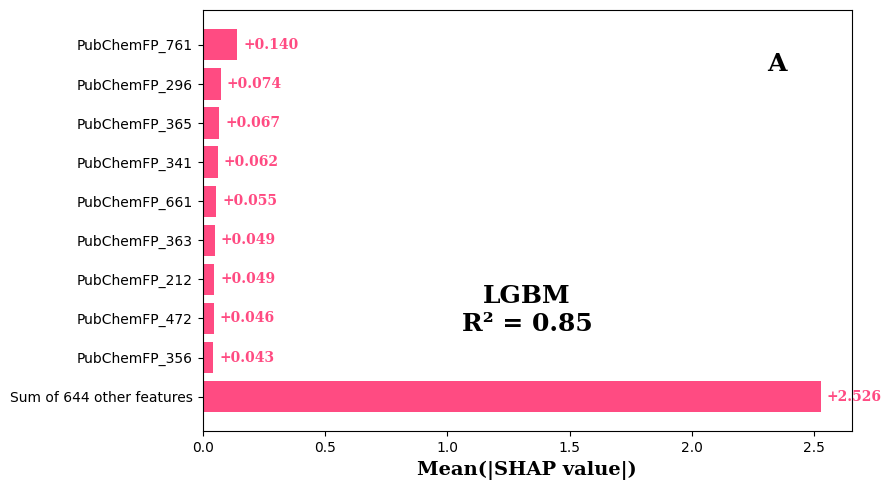

In [ ]:
plot_shap_bar(modelos_finais["LGBM"], X_teste_final, "LGBM", y_teste_final, letra="A", save_path="figs")

Figura salva em: figs/HGB_B.png


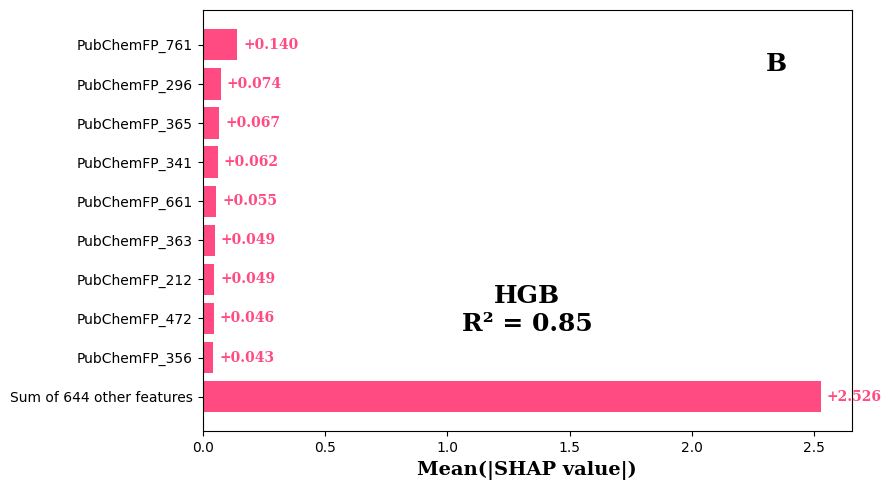

In [ ]:
plot_shap_bar(modelos_finais["HistGradientBoosting"], X_teste_final, "HGB", y_teste_final, letra="B", save_path="figs")

Figura salva em: figs/RandomForest_C.png


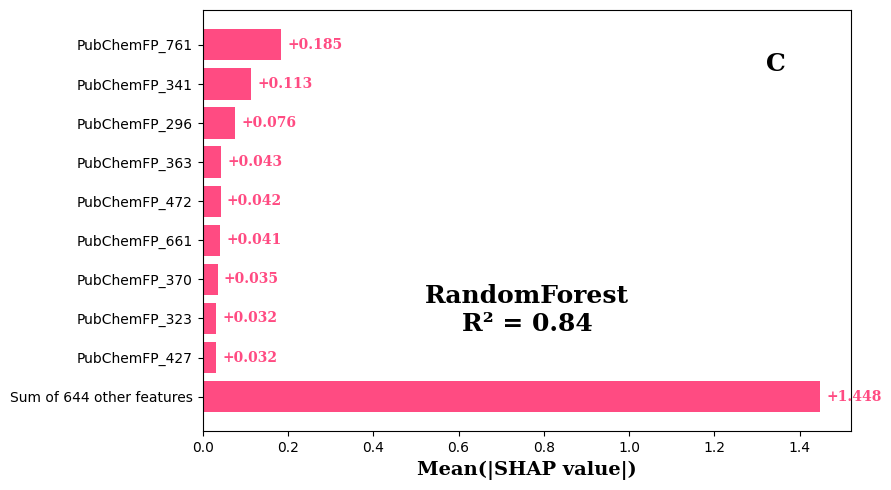

In [ ]:
plot_shap_bar(modelos_finais["RandomForest"], X_teste_final, "RandomForest", y_teste_final, letra="C", save_path="figs")

Figura salva em: figs/Bagging_D.png


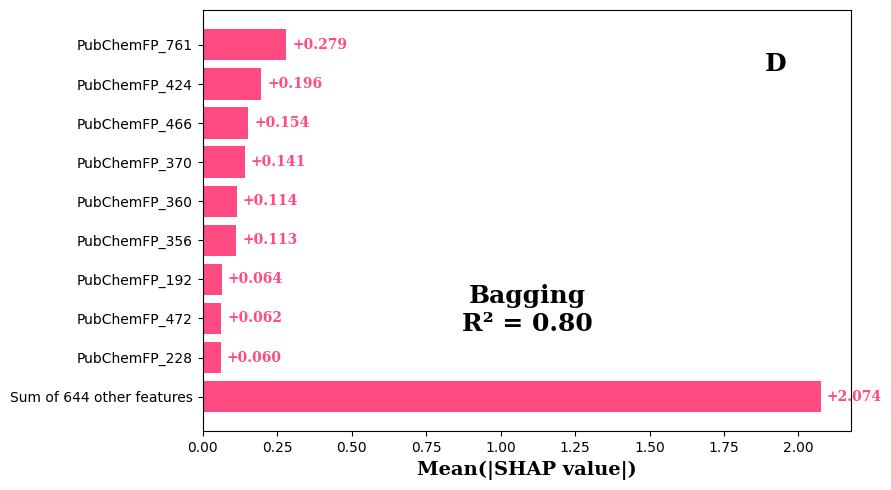

In [ ]:
plot_shap_bar(modelos_finais["Bagging"], X_teste_final, "Bagging", y_teste_final, letra="D", save_path="figs")

Figura salva em: figs/XGB_E.png


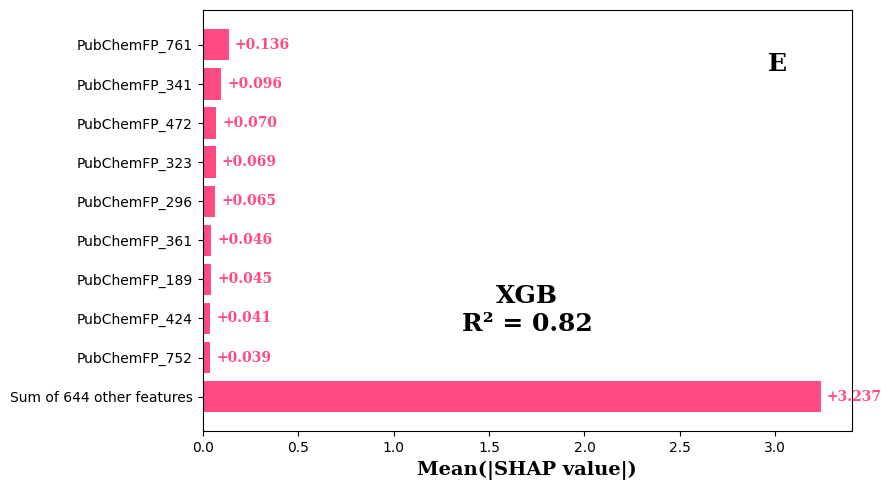

In [ ]:
plot_shap_bar(modelos_finais["XGB"], X_teste_final, "XGB", y_teste_final, letra="E", save_path="figs")

In [ ]:
def get_top_shap_features(modelo, X, y_true, top_n=5):
    """Retorna top-N features pelo valor médio de SHAP"""
    if isinstance(modelo, BaggingRegressor):
        base_model = modelo.estimators_[0]
        explainer = shap.TreeExplainer(base_model)
    else:
        explainer = shap.TreeExplainer(modelo)

    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_shap_values = np.abs(shap_values).mean(axis=0)
    df_shap = pd.DataFrame({
        "Feature": X.columns,
        "MeanSHAP": mean_shap_values
    }).sort_values(by="MeanSHAP", ascending=False)

    return df_shap.head(top_n).reset_index(drop=True)

# Obter top 20 de cada modelo
top_features_dict = {}
for nome, modelo in modelos_finais.items():
    top_features_dict[nome] = get_top_shap_features(modelo, X_teste_final, y_teste_final, top_n=6)

# Exemplo: visualizar top 10 do RandomForest
top_features_dict["RandomForest"].head(10)


,Feature,MeanSHAP
0,PubChemFP_761,0.18
1,PubChemFP_341,0.11
2,PubChemFP_296,0.08
3,PubChemFP_363,0.04
4,PubChemFP_472,0.04
5,PubChemFP_661,0.04


In [ ]:
# Unir todos os top features em uma tabela
dfs = []
for nome, df in top_features_dict.items():
    df = df.copy()
    df["Modelo"] = nome
    dfs.append(df)

df_top_all = pd.concat(dfs, ignore_index=True)

# Contar frequência das features que aparecem no top-N de vários modelos
freq = df_top_all["Feature"].value_counts().reset_index()
freq.columns = ["Feature", "N_Modelos"]

# Ordenar pelas mais "consistentes"
freq = freq.sort_values(by="N_Modelos", ascending=False)
freq.head(6)

,Feature,N_Modelos
0,PubChemFP_761,5
1,PubChemFP_296,4
2,PubChemFP_341,4
3,PubChemFP_661,3
4,PubChemFP_363,3
5,PubChemFP_365,2


In [ ]:
import pandas as pd
from rdkit import Chem

# ============================
# Suas fingerprints e descrições
# ============================
substructures = [
    {"FSM": "PubChemFP_761", "SMARTS": "Oc1c(O)cccc1", "Description": "Catecol"},
    {"FSM": "PubChemFP_296", "SMARTS": "C[Se]", "Description": "Selenometano"},
    {"FSM": "PubChemFP_341", "SMARTS": "C(C)(C)O", "Description": "Terc-butanol"},
    {"FSM": "PubChemFP_661", "SMARTS": "OCCOC", "Description": "1,2-Dietoxietano"},
    {"FSM": "PubChemFP_363", "SMARTS": "C(F)(F)", "Description": "Difluorometano"},
    {"FSM": "PubChemFP_365", "SMARTS": "C([H])([N])", "Description": "Amina primária"},
]

# ============================
# Converter SMARTS → SMILES
# ============================
rows = []
for entry in substructures:
    mol = Chem.MolFromSmarts(entry["SMARTS"])
    if mol:
        smiles = Chem.MolToSmiles(mol)
    else:
        smiles = "Inválido"
    rows.append({
        "FSM": entry["FSM"],
        "Substructure": smiles,
        "Description": entry["Description"]
    })

df_frag = pd.DataFrame(rows)
display(df_frag)

,FSM,Substructure,Description
0,PubChemFP_761,Oc1ccccc1O,Catecol
1,PubChemFP_296,C[Se],Selenometano
2,PubChemFP_341,CC(C)O,Terc-butanol
3,PubChemFP_661,COCCO,"1,2-Dietoxietano"
4,PubChemFP_363,FCF,Difluorometano
5,PubChemFP_365,[H]CN,Amina primária


# **Não**